# Module 4: K-Means Clustering for Malware Feature Analysis

**Course:** CSCE 40103: Introduction to AI for Security  
**Module:** Malware Detection and Malicious Artifact Classification  
**Notebook focus:** Use K-Means clustering to group malware artifacts represented as feature vectors.

## What this notebook teaches

By the end of this notebook, you should be able to:

1. Explain how malware artifacts become rows in a feature table.
2. Select malware-related numeric features for clustering.
3. Scale features before using K-Means.
4. Fit K-Means and inspect cluster assignments.
5. Use the elbow method and silhouette score to compare values of `K`.
6. Interpret clusters from a cybersecurity perspective.
7. Explain limitations of K-Means for malware analysis.

## Safety note

This notebook does **not** use live malware. It uses either:

- a pre-extracted malware artifact dataset if you already have one, or
- a safe synthetic dataset with malware-style PE feature columns.

The purpose is to learn clustering and interpretation, not to execute or reverse engineer malware.

## Textbook connection

This notebook follows the same idea used in the primary textbook: extracted PE file artifact fields are placed into a dataset and then clustered with K-Means. The textbook example uses fields such as `MajorLinkerVersion`, `MajorImageVersion`, `MajorOperatingSystemVersion`, and `DllCharacteristics`, then evaluates clustering with a crosstab and silhouette coefficient.

The supplementary textbook discusses malware feature generation from binaries, including byte histograms, byte entropy histograms, strings, general file information, header information, section information, imports, and exports. We use safe feature columns inspired by those categories.

## Notebook workflow

1. Import packages.
2. Load a malware artifact dataset, or create a safe textbook-style dataset.
3. Inspect rows, columns, missing values, and label distribution.
4. Select features for K-Means.
5. Scale the features.
6. Run K-Means with `K = 2`.
7. Evaluate cluster quality.
8. Use elbow and silhouette plots to compare several `K` values.
9. Visualize clusters using PCA.
10. Profile and interpret clusters.
11. Study common failure cases.
12. Answer reflection questions.

In [1]:
# Core data tools
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Matplotlib is building the font cache; this may take a moment.


# Part 1: Load or Create a Safe Malware Feature Dataset

The preferred file name is:

```text
MalwareArtifacts.csv
```

If that file is present in the same folder as the notebook, the notebook will load it.

If it is not present, the notebook creates a safe synthetic dataset named:

```text
MalwareArtifacts_Synthetic.csv
```

The synthetic dataset is **not real malware data**.

In [2]:
def make_textbook_style_malware_dataset(random_state=42):
    """Create a safe synthetic dataset with malware-style PE feature columns.

    The dataset has three underlying groups:
    1. benign_like
    2. packed_downloader_like
    3. persistence_backdoor_like

    The binary label is:
    0 = benign_like
    1 = malware-like

    This is for teaching clustering only. It is not live malware and not a real detection dataset.
    """
    rng = np.random.default_rng(random_state)

    n_benign = 420
    n_packed = 220
    n_backdoor = 220

    def clip_int(values, low=0):
        return np.maximum(np.round(values).astype(int), low)

    benign = pd.DataFrame({
        'sample_id': [f'BEN_{i:04d}' for i in range(n_benign)],
        'family': 'benign_like',
        'label': 0,
        'MajorLinkerVersion': clip_int(rng.normal(9, 1.2, n_benign), 2),
        'MajorImageVersion': clip_int(rng.normal(1.5, 1.0, n_benign), 0),
        'MajorOperatingSystemVersion': clip_int(rng.normal(6, 0.8, n_benign), 3),
        'DllCharacteristics': clip_int(rng.normal(330, 40, n_benign), 0),
        'FileSizeKB': clip_int(rng.normal(900, 280, n_benign), 50),
        'NumberOfSections': clip_int(rng.normal(5, 1.2, n_benign), 1),
        'SectionEntropyMean': np.clip(rng.normal(5.1, 0.45, n_benign), 2.5, 8.0),
        'SectionEntropyMax': np.clip(rng.normal(6.1, 0.5, n_benign), 3.0, 8.0),
        'ImportCount': clip_int(rng.normal(95, 25, n_benign), 1),
        'ExportCount': clip_int(rng.normal(5, 4, n_benign), 0),
        'StringCount': clip_int(rng.normal(850, 180, n_benign), 20),
        'URLCount': clip_int(rng.poisson(1.2, n_benign), 0),
        'RegistryStringCount': clip_int(rng.poisson(2.0, n_benign), 0),
        'SuspiciousStringCount': clip_int(rng.poisson(1.1, n_benign), 0),
        'UniqueAPICalls': clip_int(rng.normal(110, 22, n_benign), 5),
        'NetworkAPICount': clip_int(rng.poisson(3.0, n_benign), 0),
        'CryptoAPICount': clip_int(rng.poisson(1.2, n_benign), 0),
        'HasDebugSymbols': rng.binomial(1, 0.18, n_benign),
    })

    packed = pd.DataFrame({
        'sample_id': [f'PKD_{i:04d}' for i in range(n_packed)],
        'family': 'packed_downloader_like',
        'label': 1,
        'MajorLinkerVersion': clip_int(rng.normal(6, 1.4, n_packed), 2),
        'MajorImageVersion': clip_int(rng.normal(0.4, 0.5, n_packed), 0),
        'MajorOperatingSystemVersion': clip_int(rng.normal(5.5, 1.0, n_packed), 3),
        'DllCharacteristics': clip_int(rng.normal(160, 60, n_packed), 0),
        'FileSizeKB': clip_int(rng.normal(420, 170, n_packed), 30),
        'NumberOfSections': clip_int(rng.normal(3, 0.8, n_packed), 1),
        'SectionEntropyMean': np.clip(rng.normal(7.2, 0.35, n_packed), 4.0, 8.0),
        'SectionEntropyMax': np.clip(rng.normal(7.85, 0.18, n_packed), 5.0, 8.0),
        'ImportCount': clip_int(rng.normal(18, 9, n_packed), 1),
        'ExportCount': clip_int(rng.normal(0.5, 1.0, n_packed), 0),
        'StringCount': clip_int(rng.normal(130, 65, n_packed), 3),
        'URLCount': clip_int(rng.poisson(7.0, n_packed), 0),
        'RegistryStringCount': clip_int(rng.poisson(4.0, n_packed), 0),
        'SuspiciousStringCount': clip_int(rng.poisson(8.0, n_packed), 0),
        'UniqueAPICalls': clip_int(rng.normal(42, 14, n_packed), 5),
        'NetworkAPICount': clip_int(rng.poisson(12.0, n_packed), 0),
        'CryptoAPICount': clip_int(rng.poisson(6.0, n_packed), 0),
        'HasDebugSymbols': rng.binomial(1, 0.02, n_packed),
    })

    backdoor = pd.DataFrame({
        'sample_id': [f'BCK_{i:04d}' for i in range(n_backdoor)],
        'family': 'persistence_backdoor_like',
        'label': 1,
        'MajorLinkerVersion': clip_int(rng.normal(8, 1.0, n_backdoor), 2),
        'MajorImageVersion': clip_int(rng.normal(1.0, 0.8, n_backdoor), 0),
        'MajorOperatingSystemVersion': clip_int(rng.normal(6, 0.9, n_backdoor), 3),
        'DllCharacteristics': clip_int(rng.normal(220, 50, n_backdoor), 0),
        'FileSizeKB': clip_int(rng.normal(1250, 330, n_backdoor), 50),
        'NumberOfSections': clip_int(rng.normal(6, 1.1, n_backdoor), 1),
        'SectionEntropyMean': np.clip(rng.normal(5.8, 0.45, n_backdoor), 3.0, 8.0),
        'SectionEntropyMax': np.clip(rng.normal(6.8, 0.45, n_backdoor), 3.0, 8.0),
        'ImportCount': clip_int(rng.normal(145, 35, n_backdoor), 1),
        'ExportCount': clip_int(rng.normal(2, 2, n_backdoor), 0),
        'StringCount': clip_int(rng.normal(520, 160, n_backdoor), 20),
        'URLCount': clip_int(rng.poisson(3.0, n_backdoor), 0),
        'RegistryStringCount': clip_int(rng.poisson(15.0, n_backdoor), 0),
        'SuspiciousStringCount': clip_int(rng.poisson(9.0, n_backdoor), 0),
        'UniqueAPICalls': clip_int(rng.normal(185, 35, n_backdoor), 10),
        'NetworkAPICount': clip_int(rng.poisson(8.0, n_backdoor), 0),
        'CryptoAPICount': clip_int(rng.poisson(3.0, n_backdoor), 0),
        'HasDebugSymbols': rng.binomial(1, 0.04, n_backdoor),
    })

    df = pd.concat([benign, packed, backdoor], ignore_index=True)
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df

DATA_FILE = 'MalwareArtifacts.csv'
SYNTHETIC_FILE = 'MalwareArtifacts_TextbookStyle_Synthetic.csv'

if os.path.exists(DATA_FILE):
    df = pd.read_csv(DATA_FILE)
    data_source = f'Loaded instructor-provided file: {DATA_FILE}'
else:
    df = make_textbook_style_malware_dataset(RANDOM_STATE)
    df.to_csv(SYNTHETIC_FILE, index=False)
    data_source = f'Created safe synthetic dataset: {SYNTHETIC_FILE}'

data_source, df.shape

('Created safe synthetic dataset: MalwareArtifacts_TextbookStyle_Synthetic.csv',
 (860, 21))

In [3]:
df.head()

,sample_id,family,label,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,FileSizeKB,NumberOfSections,SectionEntropyMean,SectionEntropyMax,ImportCount,ExportCount,StringCount,URLCount,RegistryStringCount,SuspiciousStringCount,UniqueAPICalls,NetworkAPICount,CryptoAPICount,HasDebugSymbols
0,BCK_0074,persistence_backdoor_like,1,9,0,7,215,1671,5,5.959951,6.499608,189,1,221,2,18,7,183,9,3,0
1,PKD_0185,packed_downloader_like,1,7,0,7,192,398,3,7.284722,7.971819,10,0,141,6,1,8,50,12,8,0
2,BEN_0120,benign_like,0,8,0,7,379,889,5,5.364888,6.689225,83,8,721,0,2,0,98,3,5,0
3,BEN_0208,benign_like,0,8,0,5,273,463,7,5.928565,6.988360,107,10,840,2,0,2,120,3,2,0
4,BEN_0380,benign_like,0,9,1,6,271,495,7,4.847798,5.296872,55,0,786,1,5,2,99,3,1,0


# Part 2: Inspect the Dataset

Before clustering, inspect the dataset. Clustering does not need labels, but labels are useful here for checking whether clusters align with known categories.

In [4]:
print('Dataset source:', data_source)
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nData types:')
display(df.dtypes.to_frame('dtype'))

Dataset source: Created safe synthetic dataset: MalwareArtifacts_TextbookStyle_Synthetic.csv
Shape: (860, 21)

Columns:
['sample_id', 'family', 'label', 'MajorLinkerVersion', 'MajorImageVersion', 'MajorOperatingSystemVersion', 'DllCharacteristics', 'FileSizeKB', 'NumberOfSections', 'SectionEntropyMean', 'SectionEntropyMax', 'ImportCount', 'ExportCount', 'StringCount', 'URLCount', 'RegistryStringCount', 'SuspiciousStringCount', 'UniqueAPICalls', 'NetworkAPICount', 'CryptoAPICount', 'HasDebugSymbols']

Data types:


,dtype
sample_id,str
family,str
label,int64
MajorLinkerVersion,int64
MajorImageVersion,int64
MajorOperatingSystemVersion,int64
DllCharacteristics,int64
FileSizeKB,int64
NumberOfSections,int64
SectionEntropyMean,float64


In [5]:
missing_summary = df.isna().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()

print('Duplicate rows:', duplicate_count)
print('\nMissing values:')
display(missing_summary[missing_summary > 0].to_frame('missing_count'))

if missing_summary.sum() == 0:
    print('No missing values found.')

Duplicate rows: 0

Missing values:


,missing_count


No missing values found.


In [6]:
if 'label' in df.columns:
    label_counts = df['label'].value_counts().sort_index()
    label_percent = (label_counts / len(df) * 100).round(2)
    label_table = pd.DataFrame({'count': label_counts, 'percent': label_percent})
    print('Binary label distribution, if available:')
    display(label_table)

if 'family' in df.columns:
    family_counts = df['family'].value_counts()
    family_percent = (family_counts / len(df) * 100).round(2)
    family_table = pd.DataFrame({'count': family_counts, 'percent': family_percent})
    print('Family distribution, if available:')
    display(family_table)

Binary label distribution, if available:


,count,percent
label,,
0,420,48.84
1,440,51.16


Family distribution, if available:


,count,percent
family,,
benign_like,420,48.84
persistence_backdoor_like,220,25.58
packed_downloader_like,220,25.58


# Part 3: Choose Features for Clustering

K-Means uses numeric feature vectors. It cannot directly use strings such as file names or family names.

We will start with a small textbook-style feature set similar to the primary textbook example:

- `MajorLinkerVersion`
- `MajorImageVersion`
- `MajorOperatingSystemVersion`
- `DllCharacteristics`

Then we will try a richer malware feature set inspired by static PE feature categories.

In [7]:
parisi_feature_candidates = [
    'MajorLinkerVersion',
    'MajorImageVersion',
    'MajorOperatingSystemVersion',
    'DllCharacteristics'
]

available_parisi_features = [col for col in parisi_feature_candidates if col in df.columns]

# Fallback: use the first four numeric columns if the textbook-style feature names are unavailable.
if len(available_parisi_features) < 4:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude_cols = {'label'}
    available_parisi_features = [col for col in numeric_cols if col not in exclude_cols][:4]

available_parisi_features

['MajorLinkerVersion',
 'MajorImageVersion',
 'MajorOperatingSystemVersion',
 'DllCharacteristics']

In [8]:
feature_notes = pd.DataFrame({
    'Feature': available_parisi_features,
    'Why it may matter': [
        'Linker/build information can reflect how the file was compiled.',
        'Image version metadata may differ across software families or build pipelines.',
        'Operating system version metadata may reflect expected platform behavior.',
        'DLL characteristics encode structural/security-related PE properties.'
    ][:len(available_parisi_features)]
})
display(feature_notes)

,Feature,Why it may matter
0,MajorLinkerVersion,Linker/build information can reflect how the f...
1,MajorImageVersion,Image version metadata may differ across softw...
2,MajorOperatingSystemVersion,Operating system version metadata may reflect ...
3,DllCharacteristics,DLL characteristics encode structural/security...


# Part 4: Scale the Features

K-Means is distance-based. If one feature has much larger numeric values than another, it can dominate the distance calculation.

For example, `DllCharacteristics` may have values in the hundreds, while version fields may be small integers. Scaling prevents the larger-number feature from controlling the clustering by itself.

In [9]:
X_small = df[available_parisi_features].copy()

scaler_small = StandardScaler()
X_small_scaled = scaler_small.fit_transform(X_small)

X_small_scaled_df = pd.DataFrame(X_small_scaled, columns=available_parisi_features)
X_small_scaled_df.head()

,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics
0,0.583328,-1.120132,1.183411,-0.459162
1,-0.602635,-1.120132,1.183411,-0.717444
2,-0.009653,-1.120132,1.183411,1.382501
3,-0.009653,-1.120132,-0.939078,0.192158
4,0.583328,-0.077585,0.122166,0.169698


In [10]:
print('Original feature ranges:')
display(X_small.describe().T[['min', 'mean', 'std', 'max']].round(3))

print('\nScaled feature ranges:')
display(X_small_scaled_df.describe().T[['min', 'mean', 'std', 'max']].round(3))

Original feature ranges:


,min,mean,std,max
MajorLinkerVersion,2.0,8.016,1.687,12.0
MajorImageVersion,0.0,1.074,0.960,4.0
MajorOperatingSystemVersion,3.0,5.885,0.943,10.0
DllCharacteristics,0.0,255.888,89.102,447.0



Scaled feature ranges:


,min,mean,std,max
MajorLinkerVersion,-3.568,-0.0,1.001,2.362
MajorImageVersion,-1.120,-0.0,1.001,3.050
MajorOperatingSystemVersion,-3.062,0.0,1.001,4.367
DllCharacteristics,-2.874,-0.0,1.001,2.146


# Part 5: Run K-Means with K = 2

We start with `K = 2` because one common malware detection question is whether artifacts separate into two broad groups:

- benign-like artifacts
- malware-like or suspicious artifacts

Important: K-Means does **not** use the labels during clustering. Labels are only used afterward for interpretation and evaluation.

In [11]:
kmeans_small_k2 = KMeans(
    n_clusters=2,
    max_iter=300,
    n_init=20,
    random_state=RANDOM_STATE
)

clusters_small_k2 = kmeans_small_k2.fit_predict(X_small_scaled)

df['cluster_small_k2'] = clusters_small_k2

print('Cluster counts:')
print(pd.Series(clusters_small_k2).value_counts().sort_index())
print('\nInertia:', round(kmeans_small_k2.inertia_, 3))
print('Silhouette score:', round(silhouette_score(X_small_scaled, clusters_small_k2), 3))

Cluster counts:
0    343
1    517
Name: count, dtype: int64

Inertia: 2299.984
Silhouette score: 0.298


## Interpret cluster IDs carefully

K-Means cluster IDs are arbitrary. Cluster `0` does not automatically mean benign, and cluster `1` does not automatically mean malware.

If labels are available, we can compare them to clusters after the model is fitted.

In [12]:
if 'label' in df.columns:
    print('Crosstab: known label vs. K-Means cluster')
    display(pd.crosstab(df['label'], df['cluster_small_k2'], rownames=['Known label'], colnames=['Cluster']))

    ari = adjusted_rand_score(df['label'], df['cluster_small_k2'])
    print('Adjusted Rand Index:', round(ari, 3))
else:
    print('No known label column found. Skipping label comparison.')

Crosstab: known label vs. K-Means cluster


Cluster,0,1
Known label,,
0,15,405
1,328,112


Adjusted Rand Index: 0.496


# Part 6: Visualize K-Means Clusters with PCA

K-Means may use several features, which makes the true feature space difficult to visualize.

PCA gives us a 2D view for visualization only. The clustering is still performed on the scaled feature matrix, not on the PCA plot unless explicitly stated.

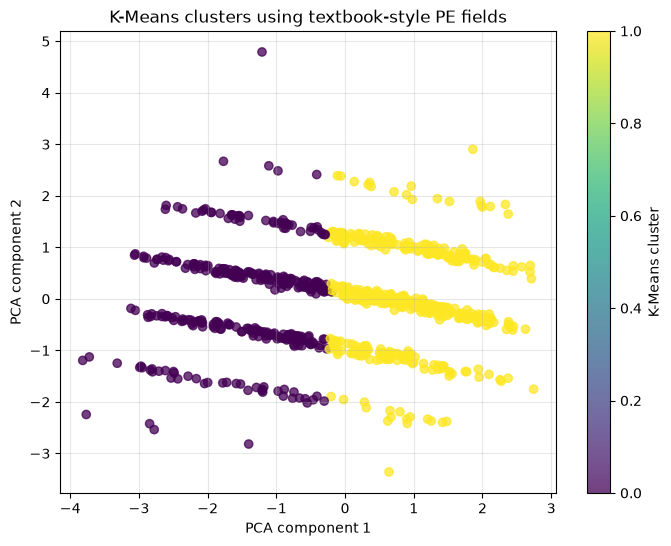

Explained variance ratio: [0.47  0.237]


In [13]:
def plot_clusters_pca(X_scaled, cluster_labels, title, known_labels=None):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, alpha=0.75)
    plt.xlabel('PCA component 1')
    plt.ylabel('PCA component 2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.colorbar(scatter, label='K-Means cluster')
    plt.show()

    print('Explained variance ratio:', np.round(pca.explained_variance_ratio_, 3))

plot_clusters_pca(X_small_scaled, clusters_small_k2, 'K-Means clusters using textbook-style PE fields')

# Part 7: Choosing K with Elbow and Silhouette Scores

K-Means requires us to choose `K` before fitting the model.

We will compare several values of `K` using:

- **Inertia:** total within-cluster variation. Lower is better, but it always decreases as K increases.
- **Silhouette score:** measures how well-separated clusters are. Higher is usually better, but it must still be interpreted carefully.

In [14]:
def evaluate_k_range(X_scaled, k_values, random_state=42):
    rows = []
    for k in k_values:
        model = KMeans(
            n_clusters=k,
            max_iter=300,
            n_init=20,
            random_state=random_state
        )
        labels = model.fit_predict(X_scaled)
        inertia = model.inertia_
        sil = np.nan
        if k >= 2:
            sil = silhouette_score(X_scaled, labels)
        rows.append({'K': k, 'inertia': inertia, 'silhouette': sil})
    return pd.DataFrame(rows)

k_values = range(1, 9)
k_eval_small = evaluate_k_range(X_small_scaled, k_values, RANDOM_STATE)
display(k_eval_small.round(3))

,K,inertia,silhouette
0,1,3440.000,NaN
1,2,2299.984,0.298
2,3,1906.321,0.242
3,4,1638.344,0.236
4,5,1466.623,0.230
5,6,1335.004,0.229
6,7,1236.424,0.230
7,8,1152.157,0.232


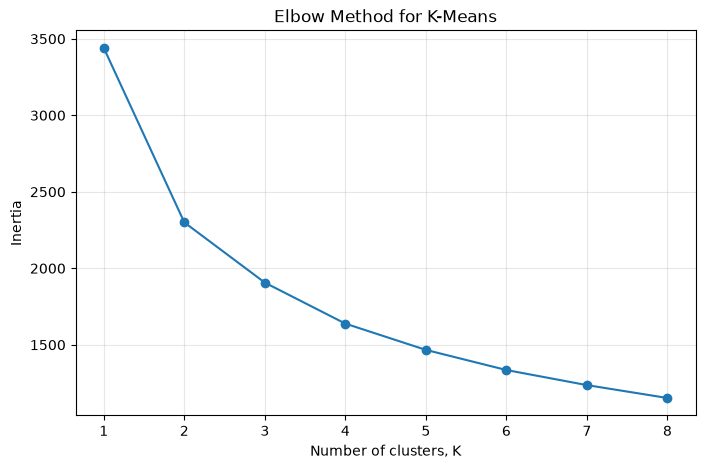

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(k_eval_small['K'], k_eval_small['inertia'], marker='o')
plt.xlabel('Number of clusters, K')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.xticks(k_eval_small['K'])
plt.grid(True, alpha=0.3)
plt.show()

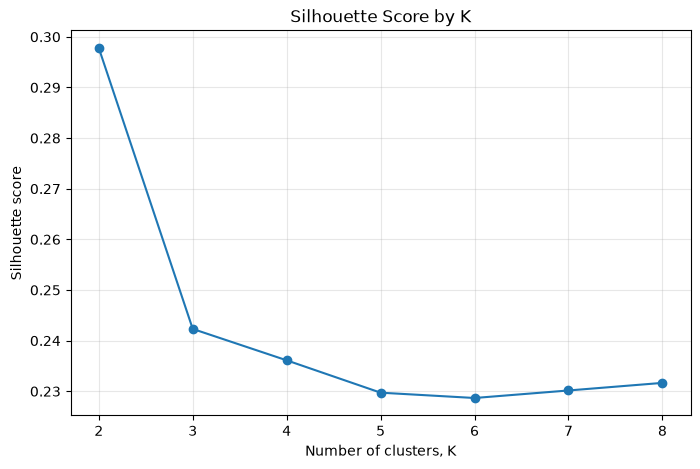

In [16]:
plt.figure(figsize=(8, 5))
plot_df = k_eval_small.dropna(subset=['silhouette'])
plt.plot(plot_df['K'], plot_df['silhouette'], marker='o')
plt.xlabel('Number of clusters, K')
plt.ylabel('Silhouette score')
plt.title('Silhouette Score by K')
plt.xticks(plot_df['K'])
plt.grid(True, alpha=0.3)
plt.show()

## Student checkpoint

Answer these questions in a markdown cell:

1. Based on the elbow plot, which `K` values look reasonable? 5
2. Based on the silhouette plot, which `K` gives the strongest separation? 5
3. If the best silhouette score is not `K = 2`, what might that mean in a malware setting? the data points are spread out
4. Why should an analyst avoid blindly trusting a single metric? The clustering might have been unlucky/lucky, best to use as an indicator

# Part 8: Use a Richer Malware Feature Set

The small feature set is useful for matching the textbook example, but malware artifacts often contain many other measurable signals.

Now we use a richer set of PE-inspired static features:

- file size
- section count
- section entropy
- import and export counts
- string counts
- URL and registry string counts
- suspicious string counts
- API call counts
- debug symbol indicator

In [17]:
rich_feature_candidates = [
    'MajorLinkerVersion',
    'MajorImageVersion',
    'MajorOperatingSystemVersion',
    'DllCharacteristics',
    'FileSizeKB',
    'NumberOfSections',
    'SectionEntropyMean',
    'SectionEntropyMax',
    'ImportCount',
    'ExportCount',
    'StringCount',
    'URLCount',
    'RegistryStringCount',
    'SuspiciousStringCount',
    'UniqueAPICalls',
    'NetworkAPICount',
    'CryptoAPICount',
    'HasDebugSymbols'
]

available_rich_features = [col for col in rich_feature_candidates if col in df.columns]

# Fallback: all numeric columns except label and generated cluster columns.
if len(available_rich_features) < 5:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude_cols = {'label', 'cluster_small_k2'}
    available_rich_features = [col for col in numeric_cols if col not in exclude_cols]

print('Number of rich features:', len(available_rich_features))
available_rich_features

Number of rich features: 18


['MajorLinkerVersion',
 'MajorImageVersion',
 'MajorOperatingSystemVersion',
 'DllCharacteristics',
 'FileSizeKB',
 'NumberOfSections',
 'SectionEntropyMean',
 'SectionEntropyMax',
 'ImportCount',
 'ExportCount',
 'StringCount',
 'URLCount',
 'RegistryStringCount',
 'SuspiciousStringCount',
 'UniqueAPICalls',
 'NetworkAPICount',
 'CryptoAPICount',
 'HasDebugSymbols']

In [18]:
X_rich = df[available_rich_features].copy()

scaler_rich = StandardScaler()
X_rich_scaled = scaler_rich.fit_transform(X_rich)

k_eval_rich = evaluate_k_range(X_rich_scaled, range(1, 9), RANDOM_STATE)
display(k_eval_rich.round(3))

,K,inertia,silhouette
0,1,15480.000,NaN
1,2,9409.197,0.393
2,3,6620.753,0.373
3,4,5975.711,0.327
4,5,5686.584,0.273
5,6,5474.866,0.267
6,7,5310.480,0.166
7,8,5130.663,0.120


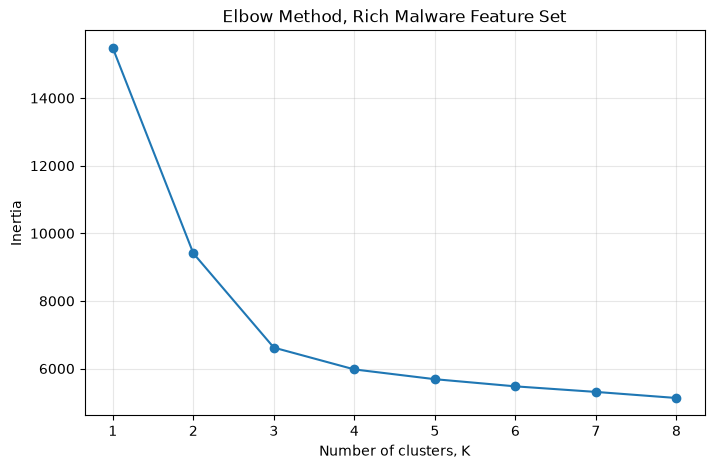

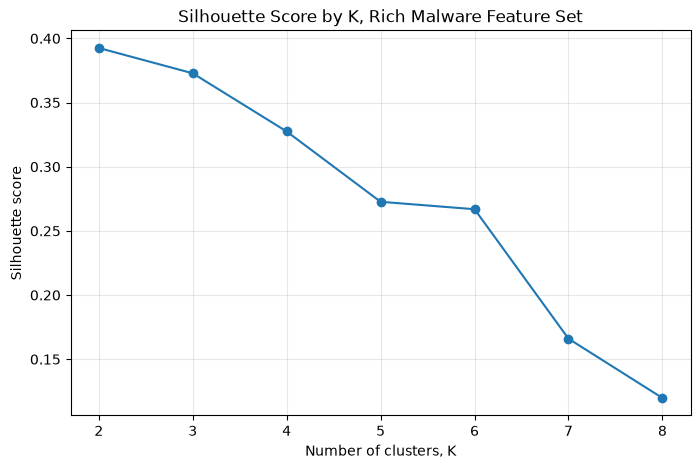

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(k_eval_rich['K'], k_eval_rich['inertia'], marker='o')
plt.xlabel('Number of clusters, K')
plt.ylabel('Inertia')
plt.title('Elbow Method, Rich Malware Feature Set')
plt.xticks(k_eval_rich['K'])
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plot_df = k_eval_rich.dropna(subset=['silhouette'])
plt.plot(plot_df['K'], plot_df['silhouette'], marker='o')
plt.xlabel('Number of clusters, K')
plt.ylabel('Silhouette score')
plt.title('Silhouette Score by K, Rich Malware Feature Set')
plt.xticks(plot_df['K'])
plt.grid(True, alpha=0.3)
plt.show()

# Part 9: Fit and Interpret a Rich Feature K-Means Model

For the synthetic dataset, `K = 3` often makes sense because it was designed with three underlying behavior groups:

1. benign-like
2. packed/downloader-like
3. persistence/backdoor-like

For a real dataset, do not assume `K = 3`. Use EDA, domain knowledge, and clustering metrics.

In [20]:
K_RICH = 3

kmeans_rich = KMeans(
    n_clusters=K_RICH,
    max_iter=300,
    n_init=20,
    random_state=RANDOM_STATE
)

clusters_rich = kmeans_rich.fit_predict(X_rich_scaled)
df['cluster_rich'] = clusters_rich

print('Cluster counts:')
print(pd.Series(clusters_rich).value_counts().sort_index())
print('\nInertia:', round(kmeans_rich.inertia_, 3))
print('Silhouette score:', round(silhouette_score(X_rich_scaled, clusters_rich), 3))

if 'label' in df.columns:
    print('\nKnown label vs cluster:')
    display(pd.crosstab(df['label'], df['cluster_rich'], rownames=['Known label'], colnames=['Cluster']))

if 'family' in df.columns:
    print('\nKnown family vs cluster:')
    display(pd.crosstab(df['family'], df['cluster_rich'], rownames=['Known family'], colnames=['Cluster']))

Cluster counts:
0    220
1    420
2    220
Name: count, dtype: int64

Inertia: 6620.753
Silhouette score: 0.373

Known label vs cluster:


Cluster,0,1,2
Known label,,,
0,0,420,0
1,220,0,220



Known family vs cluster:


Cluster,0,1,2
Known family,,,
benign_like,0,420,0
packed_downloader_like,220,0,0
persistence_backdoor_like,0,0,220


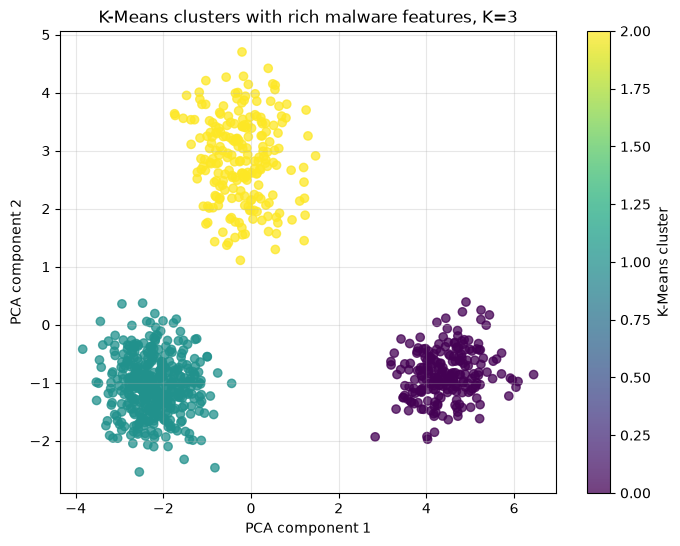

Explained variance ratio: [0.434 0.173]


In [21]:
plot_clusters_pca(X_rich_scaled, clusters_rich, f'K-Means clusters with rich malware features, K={K_RICH}')

# Part 10: Cluster Profiling

A cluster ID is not meaningful by itself. We need to inspect each cluster and describe what makes it different.

A good cluster profile answers:

- Which features are high or low in this cluster?
- Does the cluster look benign-like, packed-like, downloader-like, or persistence-like?
- What would an analyst investigate first?

In [22]:
cluster_profile = df.groupby('cluster_rich')[available_rich_features].mean().round(2)
cluster_profile

,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,FileSizeKB,NumberOfSections,SectionEntropyMean,SectionEntropyMax,ImportCount,ExportCount,StringCount,URLCount,RegistryStringCount,SuspiciousStringCount,UniqueAPICalls,NetworkAPICount,CryptoAPICount,HasDebugSymbols
cluster_rich,,,,,,,,,,,,,,,,,,
0,6.16,0.38,5.60,154.37,418.42,2.92,7.18,7.84,18.02,0.62,130.32,7.28,4.01,8.08,40.27,12.23,6.16,0.03
1,9.00,1.47,5.98,327.94,860.72,5.03,5.11,6.13,95.95,4.95,855.95,1.08,1.92,1.11,108.32,3.03,1.21,0.20
2,7.99,1.02,6.00,219.85,1261.98,5.95,5.79,6.79,145.54,2.17,526.53,2.97,14.83,9.21,187.89,7.99,3.00,0.05


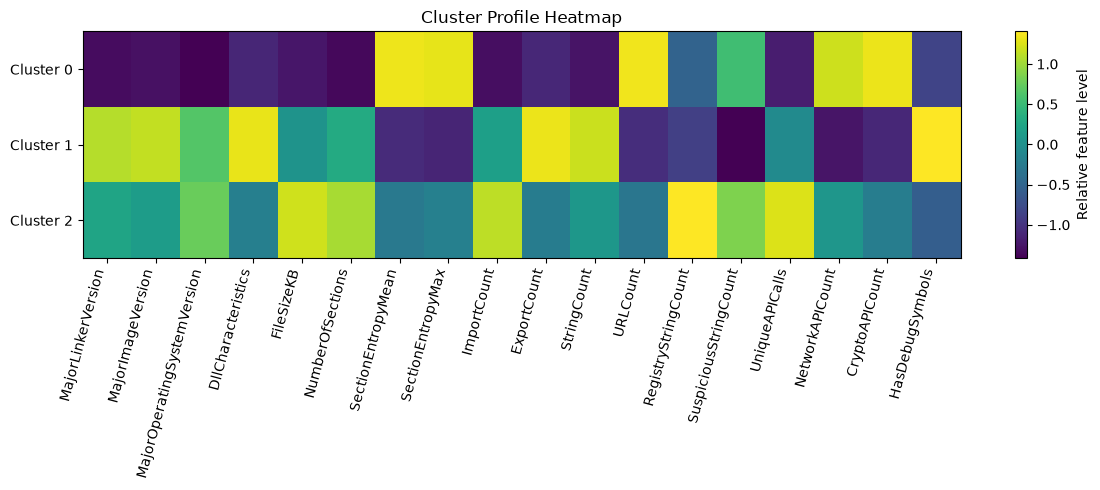

In [23]:
# Standardize the cluster profile for visualization.
# This shows whether each cluster is high or low relative to the overall dataset.
profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

plt.figure(figsize=(12, 5))
plt.imshow(profile_scaled, aspect='auto')
plt.colorbar(label='Relative feature level')
plt.yticks(range(len(profile_scaled.index)), [f'Cluster {i}' for i in profile_scaled.index])
plt.xticks(range(len(profile_scaled.columns)), profile_scaled.columns, rotation=75, ha='right')
plt.title('Cluster Profile Heatmap')
plt.tight_layout()
plt.show()

## Student interpretation task

Use the cluster profile table and heatmap to complete this table:

| Cluster | Features that are high | Features that are low | Possible interpretation |
|---|---|---|---|
| 0 | SectionEntropyMean, SectionEntropyMax, URLCount | RegistryStringCount | These features have the largest values |
| 1 |  |  |  |
| 2 |  |  |  |

Possible interpretations may include:

- benign-like software
- packed or obfuscated downloader-like artifacts
- persistence/backdoor-like artifacts
- mixed or unclear group

# Part 11: Why Scaling Matters

Now we intentionally run K-Means without scaling so we can see why scaling matters.

This is a common student mistake.

In [24]:
kmeans_unscaled = KMeans(
    n_clusters=K_RICH,
    max_iter=300,
    n_init=20,
    random_state=RANDOM_STATE
)

clusters_unscaled = kmeans_unscaled.fit_predict(X_rich)

print('Unscaled silhouette:', round(silhouette_score(X_rich, clusters_unscaled), 3))
print('Scaled silhouette:', round(silhouette_score(X_rich_scaled, clusters_rich), 3))

if 'family' in df.columns:
    print('\nKnown family vs unscaled cluster:')
    display(pd.crosstab(df['family'], clusters_unscaled, rownames=['Known family'], colnames=['Unscaled cluster']))

    print('\nKnown family vs scaled cluster:')
    display(pd.crosstab(df['family'], clusters_rich, rownames=['Known family'], colnames=['Scaled cluster']))

Unscaled silhouette: 0.471
Scaled silhouette: 0.373

Known family vs unscaled cluster:


Unscaled cluster,0,1,2
Known family,,,
benign_like,81,6,333
packed_downloader_like,0,220,0
persistence_backdoor_like,185,6,29



Known family vs scaled cluster:


Scaled cluster,0,1,2
Known family,,,
benign_like,0,420,0
packed_downloader_like,220,0,0
persistence_backdoor_like,0,0,220
